In [1]:
## Importing Libraries

import os
import json
import random
import shutil
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import yaml
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from sklearn.model_selection import train_test_split

# Reproducibility
random.seed(42)
np.random.seed(42)

print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [2]:
## Defining Paths

ROOT_DIR = Path.cwd().parent

DATASETS_DIR = ROOT_DIR / "datasets"
IMAGE_DIR = DATASETS_DIR / "CottonWeed" / "images"
ANNOTATION_FILE = DATASETS_DIR / "CottonWeed" / "weedcoco.json"
OUTPUT_DIR = DATASETS_DIR / "processed_dataset"

OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Images      : {IMAGE_DIR}")
print(f"Annotations : {ANNOTATION_FILE}")
print(f"Output      : {OUTPUT_DIR}")

Images      : c:\Users\Akshat\Desktop\Over_Here\Data Vidwan Internship\AgroWeedGuard (Capstone Project)\datasets\CottonWeed\images
Annotations : c:\Users\Akshat\Desktop\Over_Here\Data Vidwan Internship\AgroWeedGuard (Capstone Project)\datasets\CottonWeed\weedcoco.json
Output      : c:\Users\Akshat\Desktop\Over_Here\Data Vidwan Internship\AgroWeedGuard (Capstone Project)\datasets\processed_dataset


In [3]:
## Loading COCO 

with open(ANNOTATION_FILE, "r") as f:
    coco = json.load(f)
    print(sorted([c["id"] for c in coco["categories"]]))

print("=" * 50)
print("COCO ANNOTATION FILE LOADED")
print("=" * 50)

print(f"Total Images       : {len(coco['images'])}")
print(f"Total Annotations  : {len(coco['annotations'])}")
print(f"Total Categories   : {len(coco['categories'])}")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
COCO ANNOTATION FILE LOADED
Total Images       : 5648
Total Annotations  : 9388
Total Categories   : 12


In [4]:
## Display Dataset Information

categories = {category["id"]: category["name"] for category in coco["categories"]}

category_df = pd.DataFrame({
    "Category ID": categories.keys(),
    "Category Name": categories.values()
})

print("\nDataset Categories\n")
display(category_df)

print("\nFirst Five Images\n")
display(pd.DataFrame(coco["images"]).head())

print("\nFirst Five Annotations\n")
display(pd.DataFrame(coco["annotations"]).head())


Dataset Categories



,Category ID,Category Name
0,0,weed: mollugo verticillata
1,1,weed: amaranthus palmeri
2,2,weed: eclipta
3,3,weed: portulaca oleracea
4,4,weed: amaranthus tuberculatus
5,5,weed: euphorbia maculata
6,6,weed: ipomoea indica
7,7,weed: eleusine indica
8,8,weed: sida rhombifolia
9,9,weed: senna obtusifolia



First Five Images



,id,folder,file_name,path,width,height,depth,agcontext_id,license
0,0,C:\Users\gcol4791\Downloads\CottonWeedDet12\we...,20210628_iPhoneSE_YL_1.jpg,None,3024,4032,3,0,0
1,1,C:\Users\gcol4791\Downloads\CottonWeedDet12\we...,20210628_iPhoneSE_YL_10.jpg,None,3024,4032,3,0,0
2,2,C:\Users\gcol4791\Downloads\CottonWeedDet12\we...,20210628_iPhoneSE_YL_100.jpg,None,3024,4032,3,0,0
3,3,C:\Users\gcol4791\Downloads\CottonWeedDet12\we...,20210628_iPhoneSE_YL_101.jpg,None,3024,4032,3,0,0
4,4,C:\Users\gcol4791\Downloads\CottonWeedDet12\we...,20210628_iPhoneSE_YL_102.jpg,None,3024,4032,3,0,0



First Five Annotations



,image_id,id,segmented,bbox,area,segmentation,iscrowd,pose,truncated,category_id,difficult
0,0,0,0,"[708.0, 1112.0, 1600.0, 1441.0]",2305600.0,None,0.0,Unspecified,0,0,0
1,1,1,0,"[763.0, 1701.0, 896.0, 941.0]",843136.0,None,0.0,Unspecified,0,0,0
2,2,2,0,"[401.0, 1090.0, 1942.0, 1911.0]",3711162.0,None,0.0,Unspecified,0,1,0
3,3,3,0,"[721.0, 707.0, 1650.0, 1776.0]",2930400.0,None,0.0,Unspecified,0,1,0
4,4,4,0,"[741.0, 896.0, 1878.0, 1839.0]",3453642.0,None,0.0,Unspecified,0,1,0


In [5]:
## Validating COCO Structure

required_keys = ["images", "annotations", "categories"]
missing_keys = [key for key in required_keys if key not in coco]

if len(missing_keys) == 0:
    print("COCO structure validated successfully.")
else:
    print("Missing Keys:")
    print(missing_keys)

COCO structure validated successfully.


In [6]:
## Validating Images and Annotations

image_ids = {image["id"] for image in coco["images"]}
annotation_image_ids = {annotation["image_id"] for annotation in coco["annotations"]}

missing_annotations = image_ids - annotation_image_ids
orphan_annotations = annotation_image_ids - image_ids

print("=" * 50)
print("DATASET VALIDATION")
print("=" * 50)

print(f"Images                     : {len(image_ids)}")
print(f"Images with Labels         : {len(annotation_image_ids)}")

print()

print(f"Images Missing Labels      : {len(missing_annotations)}")
print(f"Orphan Annotation Entries  : {len(orphan_annotations)}")

DATASET VALIDATION
Images                     : 5648
Images with Labels         : 5648

Images Missing Labels      : 0
Orphan Annotation Entries  : 0


In [7]:
## Verifying File Existense

missing_files = []

for image in tqdm(coco["images"]):
    image_path = IMAGE_DIR / image["file_name"]

    if not image_path.exists():
        missing_files.append(image["file_name"])

print("=" * 50)
print("IMAGE FILE VALIDATION")
print("=" * 50)

print(f"Images in COCO JSON      : {len(coco['images'])}")
print(f"Missing Image Files      : {len(missing_files)}")

if len(missing_files) > 0:
    print("\nFirst Missing Files:")

    for file in missing_files[:10]:
        print(file)

else:
    print("\nAll image files are present.")

  0%|          | 0/5648 [00:00<?, ?it/s]

IMAGE FILE VALIDATION
Images in COCO JSON      : 5648
Missing Image Files      : 0

All image files are present.


In [8]:
## Checking Corrupted Images

corrupt_images = []
print("Checking Image Integrity")

for image in tqdm(coco["images"]):
    image_path = IMAGE_DIR / image["file_name"]

    try:
        img = Image.open(image_path)
        img.verify()

    except Exception:
        corrupt_images.append(image["file_name"])

print("=" * 50)
print("CORRUPTED IMAGE CHECK")
print("=" * 50)

print(f"Total Corrupted Images : {len(corrupt_images)}")

if len(corrupt_images):
    print("\nFirst Few Corrupted Images:")

    for file in corrupt_images[:10]:
        print(file)

else:
    print("\nNo corrupted images detected.")

Checking Image Integrity


  0%|          | 0/5648 [00:00<?, ?it/s]

CORRUPTED IMAGE CHECK
Total Corrupted Images : 0

No corrupted images detected.


In [9]:
## Validating Bounding Boxes

invalid_boxes = []

for ann in tqdm(coco["annotations"]):
    x, y, w, h = ann["bbox"]

    if w <= 0 or h <= 0:
        invalid_boxes.append(ann["id"])

print("=" * 50)
print("BOUNDING BOX VALIDATION")
print("=" * 50)

print(f"Total Bounding Boxes : {len(coco['annotations'])}")
print(f"Invalid Bounding Boxes : {len(invalid_boxes)}")

if len(invalid_boxes):
    print("\nFirst Few Invalid IDs")
    print(invalid_boxes[:10])

else:
    print("\nAll bounding boxes are valid.")

  0%|          | 0/9388 [00:00<?, ?it/s]

BOUNDING BOX VALIDATION
Total Bounding Boxes : 9388
Invalid Bounding Boxes : 0

All bounding boxes are valid.


In [10]:
## Checking Datasets Statistics

image_widths = []
image_heights = []
boxes_per_image = defaultdict(int)

for image in coco["images"]:
    image_widths.append(image["width"])
    image_heights.append(image["height"])

for ann in coco["annotations"]:
    boxes_per_image[ann["image_id"]] += 1

stats = pd.DataFrame({
    "Metric":[
        "Images",
        "Annotations",
        "Categories",
        "Average Width",
        "Average Height",
        "Average Boxes/Image",
        "Maximum Boxes/Image",
        "Minimum Boxes/Image"],

    "Value":[
        len(coco["images"]),
        len(coco["annotations"]),
        len(coco["categories"]),
        np.mean(image_widths),
        np.mean(image_heights),
        np.mean(list(boxes_per_image.values())),
        np.max(list(boxes_per_image.values())),
        np.min(list(boxes_per_image.values()))]})

display(stats)

,Metric,Value
0,Images,5648.000000
1,Annotations,9388.000000
2,Categories,12.000000
3,Average Width,3451.656161
4,Average Height,3746.543024
5,Average Boxes/Image,1.662181
6,Maximum Boxes/Image,32.000000
7,Minimum Boxes/Image,1.000000


,Class,Instances
4,weed: amaranthus tuberculatus,1959
6,weed: ipomoea indica,1344
3,weed: portulaca oleracea,992
0,weed: mollugo verticillata,962
5,weed: euphorbia maculata,956
11,weed: ambrosia artemisiifolia,896
2,weed: eclipta,865
8,weed: sida rhombifolia,486
1,weed: amaranthus palmeri,348
9,weed: senna obtusifolia,243


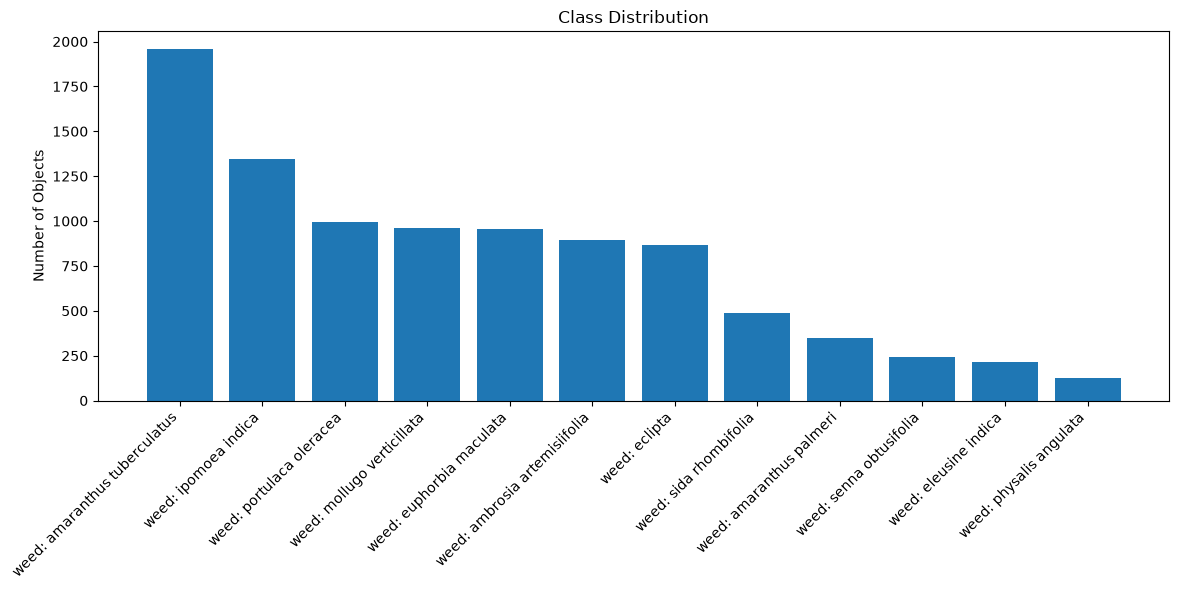

In [11]:
## Plotting Class Distribution

class_counts = Counter()

for ann in coco["annotations"]:
    class_counts[categories[ann["category_id"]]] += 1

class_df = pd.DataFrame({"Class":class_counts.keys(), "Instances":class_counts.values()})
class_df = class_df.sort_values(by="Instances", ascending=False)

display(class_df)

plt.figure(figsize=(12,6))
plt.bar(class_df["Class"], class_df["Instances"])

plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.show()

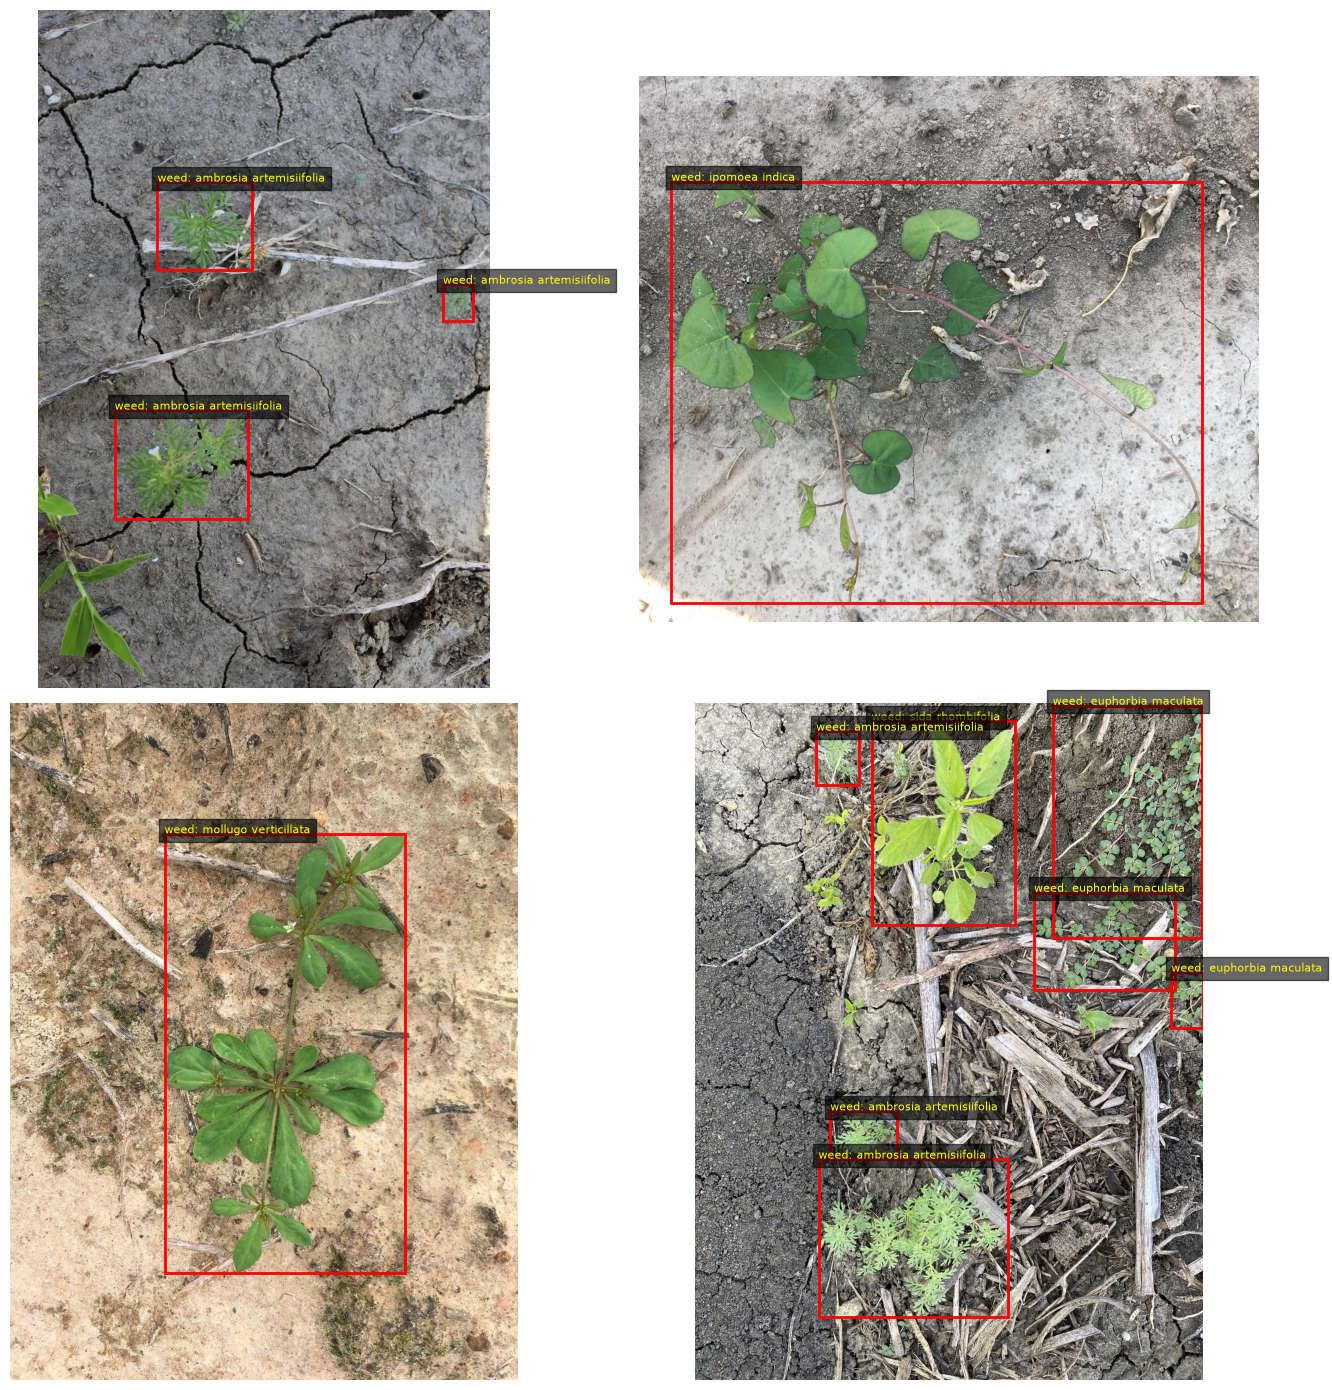

In [12]:
## Visualizing Random Samples

random_images = random.sample(coco["images"], 4)
fig, axes = plt.subplots(2,2, figsize=(14,14))
axes = axes.flatten()

for ax, image in zip(axes, random_images):
    image_path = IMAGE_DIR / image["file_name"]
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)

    for ann in coco["annotations"]:
        if ann["image_id"] != image["id"]:
            continue

        x,y,w,h = ann["bbox"]
        rect = patches.Rectangle((x,y), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y-5, categories[ann["category_id"]], fontsize=8, color="yellow", bbox=dict(facecolor="black", alpha=0.6))

    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
## Validating Bounding Boxes

image_lookup = {image["id"]: image for image in coco["images"]}
out_of_bounds = []

for ann in tqdm(coco["annotations"]):
    image = image_lookup[ann["image_id"]]

    img_w = image["width"]
    img_h = image["height"]

    x, y, w, h = ann["bbox"]

    if (
        x < 0 or
        y < 0 or
        x + w > img_w or
        y + h > img_h
    ):

        out_of_bounds.append(ann["id"])

print("=" * 50)
print("BOUNDING BOX LIMIT VALIDATION")
print("=" * 50)

print(f"Out-of-Bounds Boxes : {len(out_of_bounds)}")

if out_of_bounds:
    print(out_of_bounds[:10])
    
else:
    print("All bounding boxes lie within image boundaries.")

  0%|          | 0/9388 [00:00<?, ?it/s]

BOUNDING BOX LIMIT VALIDATION
Out-of-Bounds Boxes : 38
[650, 666, 719, 885, 982, 1115, 1279, 1685, 1706, 1714]


In [14]:
## Removing Invalid Annotations

invalid_ids = set(invalid_boxes + out_of_bounds)
clean_annotations = [ann for ann in coco["annotations"] if ann["id"] not in invalid_ids]

removed = len(coco["annotations"]) - len(clean_annotations)
coco["annotations"] = clean_annotations

print("=" * 50)
print("ANNOTATION CLEANING")
print("=" * 50)

print(f"Removed Annotations : {removed}")
print(f"Remaining           : {len(coco['annotations'])}")

ANNOTATION CLEANING
Removed Annotations : 38
Remaining           : 9350


In [15]:
## Creating Output Directories

folders = [
    OUTPUT_DIR / "images",
    OUTPUT_DIR / "labels",

    OUTPUT_DIR / "images" / "train",
    OUTPUT_DIR / "images" / "val",
    OUTPUT_DIR / "images" / "test",

    OUTPUT_DIR / "labels" / "train",
    OUTPUT_DIR / "labels" / "val",
    OUTPUT_DIR / "labels" / "test"]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Folder structure created successfully.")

Folder structure created successfully.


In [16]:
## Creating Train Test Validation Split


images_df = pd.DataFrame(coco["images"])
image_primary_class = {}

for ann in coco["annotations"]:
    if ann["image_id"] not in image_primary_class:
        image_primary_class[ann["image_id"]] = ann["category_id"]

images_df["category"] = images_df["id"].map(image_primary_class)

images_df = images_df.dropna(subset=["category"])

train_df, temp_df = train_test_split(images_df, test_size=0.30, stratify=images_df["category"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["category"], random_state=42)

splits = {"train": train_df, "val": val_df, "test": test_df}

print("=" * 50)
print("DATASET SPLIT")
print("=" * 50)

print(f"Train : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test : {len(test_df)}")

DATASET SPLIT
Train : 3948
Validation : 846
Test : 847


In [17]:
## Copying Images & Making YOLO Labels

annotations_lookup = defaultdict(list)

for ann in coco["annotations"]:
    annotations_lookup[ann["image_id"]].append(ann)

for split_name, split_df in splits.items():
    image_output = OUTPUT_DIR / "images" / split_name
    label_output = OUTPUT_DIR / "labels" / split_name

    for _, image in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name}"):
        source = IMAGE_DIR / image["file_name"]
        destination = image_output / image["file_name"]

        shutil.copy2(source, destination)
        width = image["width"]
        height = image["height"]

        yolo_lines = []

        for ann in annotations_lookup[image["id"]]:
            x, y, w, h = ann["bbox"]

            x_center = (x + w / 2) / width
            y_center = (y + h / 2) / height
            w /= width
            h /= height

            class_id = ann["category_id"]

            yolo_lines.append(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{w:.6f} "
                f"{h:.6f}"
            )

        label_path = label_output / (Path(image["file_name"]).stem + ".txt")

        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines))

print("\nDataset exported successfully.")
print("Images copied.")
print("YOLO labels generated.")

Processing train:   0%|          | 0/3948 [00:00<?, ?it/s]

Processing val:   0%|          | 0/846 [00:00<?, ?it/s]

Processing test:   0%|          | 0/847 [00:00<?, ?it/s]


Dataset exported successfully.
Images copied.
YOLO labels generated.


In [18]:
## Generating data.yaml

yaml_data = {"path": str(OUTPUT_DIR), "train": "images/train", "val": "images/val", "test": "images/test", "nc": len(categories), "names": [categories[i] for i in sorted(categories.keys())]}

with open(OUTPUT_DIR / "data.yaml", "w") as f:
    yaml.dump(yaml_data, f, sort_keys=False)

print("data.yaml created successfully.")

data.yaml created successfully.


In [19]:
## Final Verifications

summary = []

for split in ["train", "val", "test"]:
    image_count = len(list((OUTPUT_DIR/"images"/split).glob("*")))
    label_count = len(list((OUTPUT_DIR/"labels"/split).glob("*.txt")))

    summary.append({"Split":split, "Images":image_count, "Labels":label_count, "Match":image_count==label_count})

summary_df = pd.DataFrame(summary)
display(summary_df)

total_images = summary_df["Images"].sum()

print("="*70)
print("PREPROCESSING COMPLETED")
print("="*70)

print(f"Total Images Processed : {total_images}")
print(f"Dataset Location : {OUTPUT_DIR}")
print("YOLO Dataset Ready")
print("Notebook 1 Completed Successfully")

,Split,Images,Labels,Match
0,train,3948,3948,True
1,val,846,846,True
2,test,847,847,True


PREPROCESSING COMPLETED
Total Images Processed : 5641
Dataset Location : c:\Users\Akshat\Desktop\Over_Here\Data Vidwan Internship\AgroWeedGuard (Capstone Project)\datasets\processed_dataset
YOLO Dataset Ready
Notebook 1 Completed Successfully
